In [17]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from openpyxl import load_workbook

unfaelle = pd.read_excel(
    "Daten/merged_data.xlsx",
    sheet_name="merged"
)

unfaelle.head()

,Jahr,Gruppe,Unfälle_total,Unfälle_leicht,Unfälle_schwer,Unfälle_tödlich,Bevölkerung
0,2015,0-19,617,482,130,5,1674330.0
1,2015,20-90+,3014,2027,930,57,6655670.0
2,2016,0-19,595,464,126,5,1692420.0
3,2016,20-90+,2742,1870,835,37,6727580.0
4,2017,0-19,775,636,134,5,1696000.0


In [18]:
data = pd.read_excel("Daten/merged_data.xlsx", sheet_name=0)

# 1) Spalten prüfen
print(data.columns.tolist())

# 2) Dimensionen prüfen (sollte 20 Zeilen sein: 10 Jahre * 2 Gruppen)
print("shape:", data.shape)

# 3) Jahre/Gruppe prüfen
print("Jahre:", sorted(data["Jahr"].unique()))
print("Gruppen:", data["Gruppe"].unique())

['Jahr', 'Gruppe', 'Unfälle_total', 'Unfälle_leicht', 'Unfälle_schwer', 'Unfälle_tödlich', 'Bevölkerung']
shape: (20, 7)
Jahre: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Gruppen: ['0-19' '20-90+']


In [19]:
# 1) Daten laden (nur noch 1 konsolidiertes Blatt!)
data = pd.read_excel("Daten/merged_data.xlsx", sheet_name=0)

# 2) Typen sauber setzen
data["Jahr"] = pd.to_numeric(data["Jahr"], errors="coerce").astype(int)

# 3) Indikatorvariable für jung (0–19)
data["jung"] = (data["Gruppe"] == "0-19").astype(int)

# 4) Offset für Poisson (Bevölkerung)
data["log_bev"] = np.log(data["Bevölkerung"])

# 5) Raten pro 1'000 (genau wie du es schon gemacht hast)
data["Unfallrate_1000"]      = data["Unfälle_total"]   / data["Bevölkerung"] * 1000
data["Rate_leicht_1000"]     = data["Unfälle_leicht"]  / data["Bevölkerung"] * 1000
data["Rate_schwer_1000"]     = data["Unfälle_schwer"]  / data["Bevölkerung"] * 1000
data["Rate_toedlich_1000"]   = data["Unfälle_tödlich"] / data["Bevölkerung"] * 1000

# Optional: Ordnung
data = data.sort_values(["Gruppe", "Jahr"]).reset_index(drop=True)

data.head(20)

,Jahr,Gruppe,Unfälle_total,Unfälle_leicht,Unfälle_schwer,Unfälle_tödlich,Bevölkerung,jung,log_bev,Unfallrate_1000,Rate_leicht_1000,Rate_schwer_1000,Rate_toedlich_1000
0,2015,0-19,617,482,130,5,1674330.0,1,14.330924,0.368506,0.287876,0.077643,0.002986
1,2016,0-19,595,464,126,5,1692420.0,1,14.341670,0.351568,0.274164,0.074450,0.002954
2,2017,0-19,775,636,134,5,1696000.0,1,14.343783,0.456958,0.375000,0.079009,0.002948
3,2018,0-19,608,487,120,1,1708000.0,1,14.350834,0.355972,0.285129,0.070258,0.000585
4,2019,0-19,499,377,119,3,1722000.0,1,14.358997,0.289779,0.218931,0.069106,0.001742
5,2020,0-19,536,407,122,7,1725330.0,1,14.360929,0.310665,0.235897,0.070711,0.004057
6,2021,0-19,798,601,193,4,1739260.0,1,14.368970,0.458816,0.345549,0.110967,0.002300
7,2022,0-19,896,687,200,9,1755180.0,1,14.378082,0.510489,0.391413,0.113948,0.005128
8,2023,0-19,1052,776,265,11,1792000.0,1,14.398843,0.587054,0.433036,0.147879,0.006138
9,2024,0-19,1089,831,247,11,1800950.0,1,14.403825,0.604681,0.461423,0.137150,0.006108


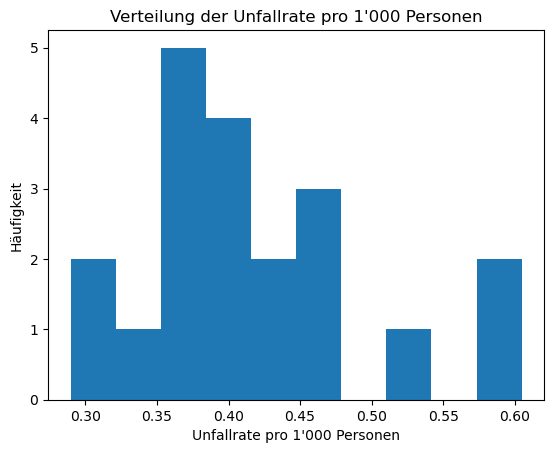

In [20]:
plt.figure()
plt.hist(data["Unfallrate_1000"], bins=10)
plt.xlabel("Unfallrate pro 1'000 Personen")
plt.ylabel("Häufigkeit")
plt.title("Verteilung der Unfallrate pro 1'000 Personen")
plt.show()

Interpretation: Unfallrate pro 1000 personen liegt hauptsächlich zwischen 0.33-0.46.
Verteilung: Ist nicht symetrisch, sie ist leicht rechtsschief.
Normalverteilung: Nicht perfekt Normalverteilt, aber auch nicht extrem schief.
Ausreisser: Einzelne höhere Werte bei 0.55-0.6.
Bedeutung: Die meisten Beobachtungen konzentrieren sich um mittleren Bereich. Hohe Unfallrate selten aber existent.
Relativ stabile Unfallraten, deutet auf zeit- oder gruppenspezifische Effekte hin und nicht zufälliges Rauschen.

In [21]:
needed = [
    "Jahr",
    "Gruppe",
    "Unfälle_total",
    "Unfälle_leicht",
    "Unfälle_schwer",
    "Unfälle_tödlich",
    "Bevölkerung"
]

missing = [c for c in needed if c not in data.columns]

if missing:
    raise ValueError(f"Fehlende Spalten: {missing}")
else:
    print("Alle benötigten Spalten vorhanden ✔")

Alle benötigten Spalten vorhanden ✔


<Figure size 640x480 with 0 Axes>

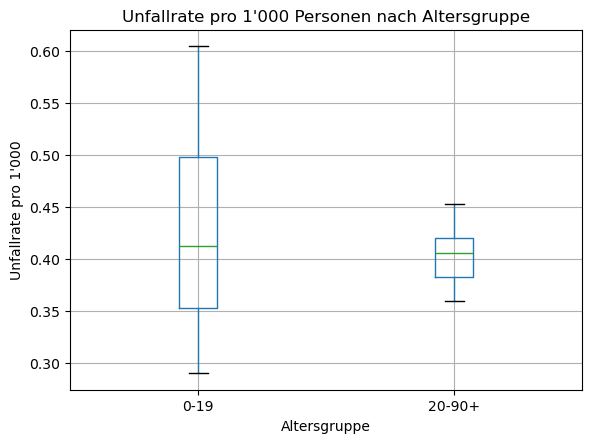

In [22]:
plt.figure()
data.boxplot(column="Unfallrate_1000", by="Gruppe")
plt.xlabel("Altersgruppe")
plt.ylabel("Unfallrate pro 1'000")
plt.title("Unfallrate pro 1'000 Personen nach Altersgruppe")
plt.suptitle("")  # entfernt automatische Zusatzüberschrift
plt.show()

Interpretation
Median: Gruppe 0-19 Jahre Median von ca. 0.41 Unfälle pro 1000 Personen.
Gruppe 20-90+ Jahre Median von ca. 40.5 Unfälle pro 1000 Personen. Beider Gruppen sehr ähnliche Medianwerte.
Streuung: Gruppe 0-19 Jahre hat Ratnwerte von 0.29-0.61, deutlich grössere Streung als Kontrollgruppe.
Gruppe 20-90+ Jahre hat Ratenwerte von 0.36-0.45. Relativ kompakte Verteilung.
Die Unfallrate der jüngeren Gruppe schwankt deutlich stärker über die Jahre als die der Kontrollgruppe.

<Figure size 640x480 with 0 Axes>

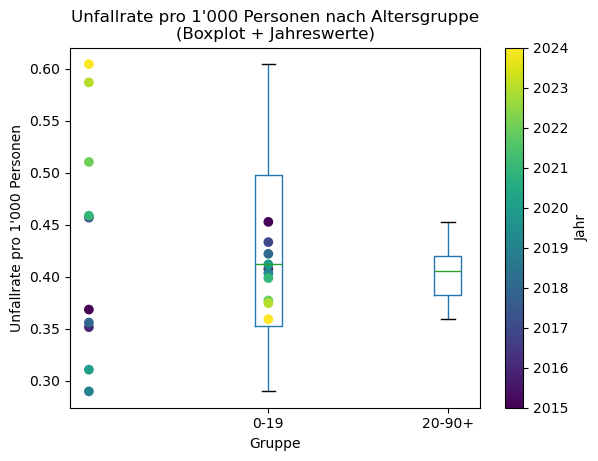

In [23]:
plt.figure()

# Boxplot
data.boxplot(
    column="Unfallrate_1000",
    by="Gruppe",
    grid=False
)

# Punkte mit Jahr als Farbe
scatter = plt.scatter(
    x=data["Gruppe"],
    y=data["Unfallrate_1000"],
    c=data["Jahr"]
)

plt.colorbar(scatter, label="Jahr")

plt.suptitle("")
plt.title("Unfallrate pro 1'000 Personen nach Altersgruppe\n(Boxplot + Jahreswerte)")
plt.ylabel("Unfallrate pro 1'000 Personen")
plt.show()

Interpretation
Kontrolle der Ausreisser: Die höheren Unfallraten lassen sich bei der Altersgruppe 0-19 in den letzten Jahren einordnen.
Keine statistische ausreisser sondern ein zeitabhängiger Effekt.


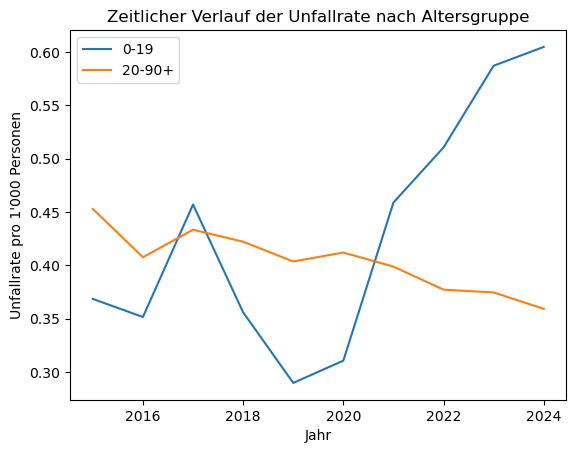

In [24]:
for grp in data["Gruppe"].unique():
    d = data[data["Gruppe"] == grp]
    plt.plot(d["Jahr"], d["Unfallrate_1000"], label=grp)

plt.xlabel("Jahr")
plt.ylabel("Unfallrate pro 1'000 Personen")
plt.title("Zeitlicher Verlauf der Unfallrate nach Altersgruppe")
plt.legend()
plt.show()

Interpretation
Gruppe 0-19: Zunächst schwanken die Raten zwischen 2015-2019. 2019 wird ein Minimum erreicht bei ca. 0.3.
Ab 2021 ist ein klarer kontinuierlicher Anstieg erkennbar. Höchstwerte bei 2023-2024 mit einem Maximum bei ca. 0.6.
Dies deutet auf strukturellen Bruch hin bzw. Trendwechsel hin. Die steigend hohen Werte ab 2021 sind keine Ausreisser sonder neue Niveaus.
Gruppe 20-90+: Die Unfallrate ist im gesamten Zeitraum duetlich stabiler. Es ist fast durchgehen einAbwärtstrend zu erkennen ohne Sprünge oder Extrempunkte.
Vergleich: Bis 2020 ist die Kontrollgruppe (20-90+) meist über der Gruppe der 0-19 jährigen. Ab 2021 kehrt sich dieses Verhältnis um. 
Es liegt ein altergruppenspezifischer Effekt vor, der Zeitlich klar begrenz ist (2021).

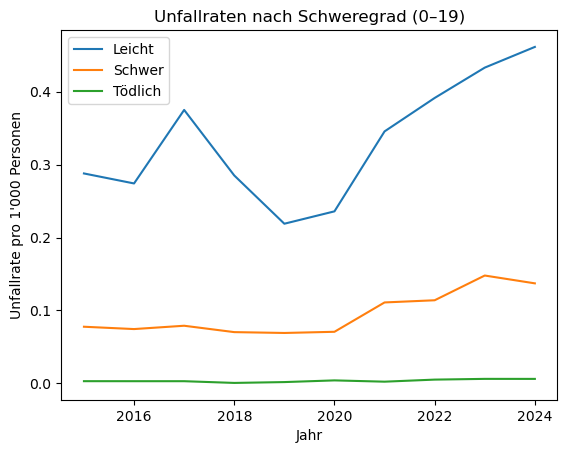

In [25]:
subset = data[data["Gruppe"] == "0-19"].sort_values("Jahr")

plt.figure()
plt.plot(subset["Jahr"], subset["Rate_leicht_1000"], label="Leicht")
plt.plot(subset["Jahr"], subset["Rate_schwer_1000"], label="Schwer")
plt.plot(subset["Jahr"], subset["Rate_toedlich_1000"], label="Tödlich")

plt.xlabel("Jahr")
plt.ylabel("Unfallrate pro 1'000 Personen")
plt.title("Unfallraten nach Schweregrad (0–19)")
plt.legend()
plt.show()

Interpretation
Leichte Unfälle: Die Unfallrate für leichte Unfälle ist im gesamten Zeitraum am höchsten. Bis 2019 ist ein leichter Rückgang erkennbar.
Ab 2021 folgt ein starker kontinuierlicher Anstieg. In 2023-2024 werden die Höchstwerte des Zeitraumes erreicht.
Schwere Unfälle: Die Unfallrate für schwere Unfälle ist duetlich tiefer als die leichten. Bis 2019 hält sie ein relativ stabiles Niveau.
Aber auch hier ab 2020/2021 folgt ein klarer Anstieg mit Höchstwerten im Jahr 2023
Tödliche Unfälle: Sind im gesamten Zeitraum sehr teif, es gibt keine Starken Ausschläge oder Trends. Leichte Schwankung bleiben aber nahe 0.